In [1]:
import joblib

best_model_fraud = joblib.load(
    "../models/fraud_best_model.pkl"
)

In [2]:
import sys
sys.path.append("../src")
from utils import load_data
from explainability import plot_feature_importance
from preprocessing import (
    load_data,
    data_cleaning_pipeline,encode_features,scale_features
)

In [3]:
print("X_test" in globals())

False


In [4]:
fraud_df = load_data('../data/raw/Fraud_Data.csv')

2026-06-13 14:48:34,791 - INFO - Loaded ../data/raw/Fraud_Data.csv


In [5]:
fraud_df = data_cleaning_pipeline(
    fraud_df
)

fraud_df.head()

2026-06-13 14:48:34,935 - INFO - Removed 0 duplicates
2026-06-13 14:48:35,101 - INFO - Data types corrected
2026-06-13 14:48:35,191 - INFO - Missing values handled


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [6]:
fraud_df = encode_features(
    fraud_df,
    ['source','browser','sex']
)
fraud_df = scale_features(
    fraud_df,
    ['age', 'purchase_value']
)

In [7]:
# Target variable
target_fraud = fraud_df["class"]

# Features
features_fraud = fraud_df.drop(
    columns=[
        "class",          # target
        "user_id",        # identifier
        "device_id",      # identifier
        "signup_time",    # original datetime
        "purchase_time"   # original datetime
    ],
    errors="ignore"
)

In [8]:
# Target variable
target_fraud = fraud_df["class"]

# Features
features_fraud = fraud_df.drop(
    columns=[
        "class",          # target
        "user_id",        # identifier
        "device_id",      # identifier
        "signup_time",    # original datetime
        "purchase_time"   # original datetime
    ],
    errors="ignore"
)

In [9]:
from sklearn.model_selection import train_test_split
X = features_fraud
y = target_fraud

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )
)

In [10]:
X = fraud_df.drop(
    columns=[
        'class',
        'user_id',
        'device_id',
        'signup_time',
        'purchase_time'
    ]
)

y = fraud_df['class']

In [11]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(120889, 10)
(30223, 10)
(120889,)
(30223,)


In [12]:
print(type(best_model_fraud))

<class 'xgboost.sklearn.XGBClassifier'>


In [13]:
print(features_fraud.columns.tolist())

['purchase_value', 'age', 'ip_address', 'source_Direct', 'source_SEO', 'browser_FireFox', 'browser_IE', 'browser_Opera', 'browser_Safari', 'sex_M']


In [14]:
print("Columns:", len(X_test.columns))
print("Importances:", len(best_model_fraud.feature_importances_))

Columns: 10
Importances: 10


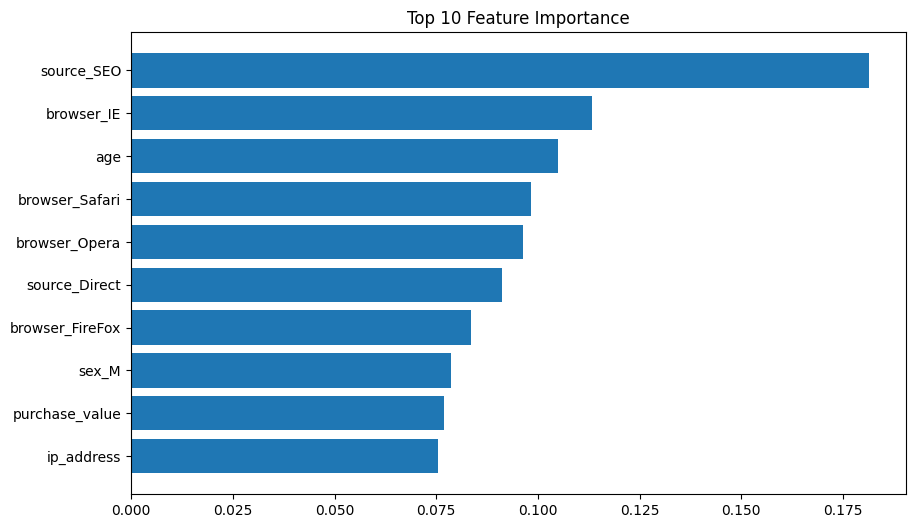

,Feature,Importance
4,source_SEO,0.181420
6,browser_IE,0.113248
1,age,0.104994
8,browser_Safari,0.098393
7,browser_Opera,0.096376
3,source_Direct,0.091087
5,browser_FireFox,0.083668
9,sex_M,0.078586
0,purchase_value,0.076867
2,ip_address,0.075360


In [15]:
importance_df = plot_feature_importance(
    best_model_fraud,
    X_test,
    top_n=10
)

importance_df

In [16]:
from explainability import (
    create_shap_explainer,
    shap_summary_plot
)

In [17]:
explainer = create_shap_explainer(
best_model_fraud)

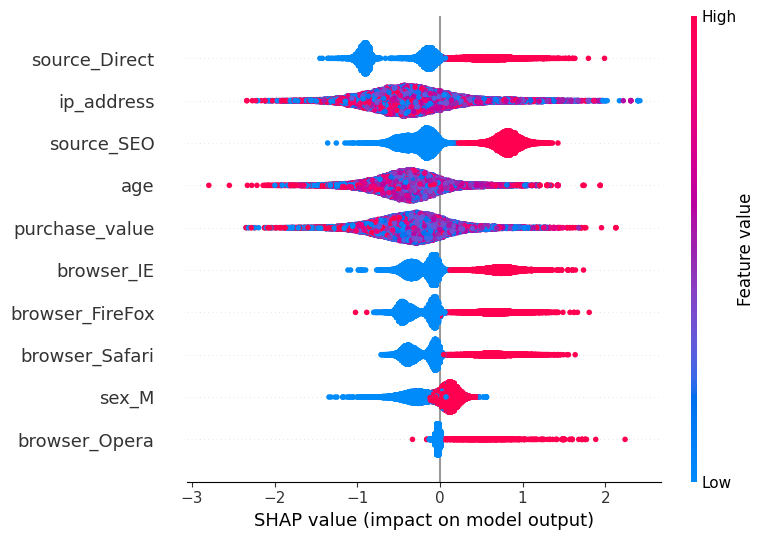

In [18]:
shap_values = shap_summary_plot(
    explainer,
    X_test
)

In [19]:
y_pred = best_model_fraud.predict(
    X_test
)

True Positive

In [20]:
results = X_test.copy()

results["actual"] = y_test.values
results["predicted"] = y_pred

False Positive

In [21]:
fp_idx = results[
    (results.actual == 0)
    &
    (results.predicted == 1)
].index[0]

fp_idx

np.int64(56953)

False Negative

In [22]:
fn_idx = results[
    (results.actual == 1)
    &
    (results.predicted == 0)
].index[0]

fn_idx

np.int64(139427)

In [23]:
from explainability import shap_force_plot

In [27]:
y_pred = best_model_fraud.predict(X_test)

In [28]:
import numpy as np

tp_idx = np.where((y_test == 1) & (y_pred == 1))[0][0]

fp_idx = np.where((y_test == 0) & (y_pred == 1))[0][0]

fn_idx = np.where((y_test == 1) & (y_pred == 0))[0][0]

print("TP:", tp_idx)
print("FP:", fp_idx)
print("FN:", fn_idx)

TP: 29
FP: 47
FN: 2


True Positive

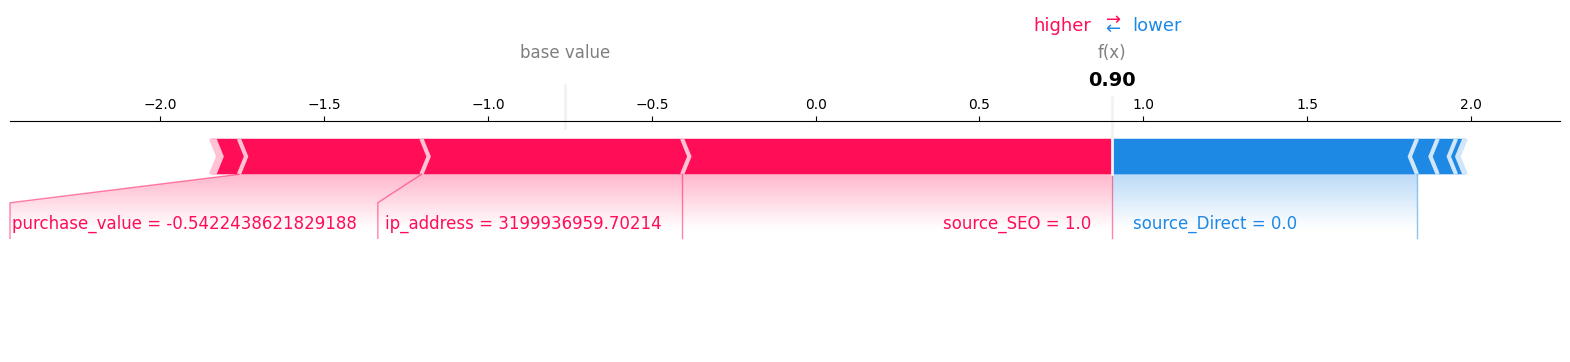

In [29]:
shap_force_plot(
    explainer,
    shap_values,
    X_test,
    tp_idx
)

False Positive

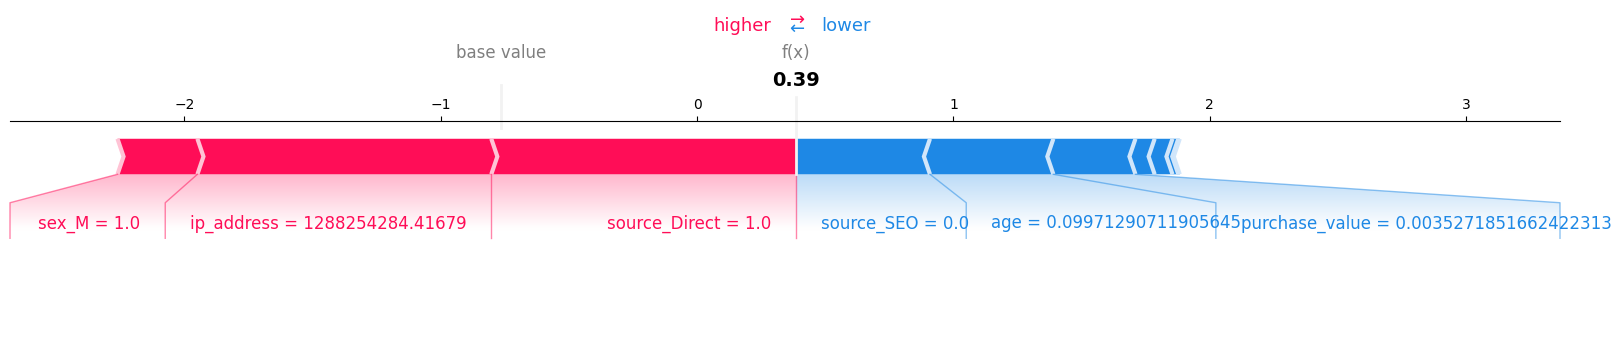

In [30]:
shap_force_plot(
    explainer,
    shap_values,
    X_test,
    fp_idx
)

False Negative

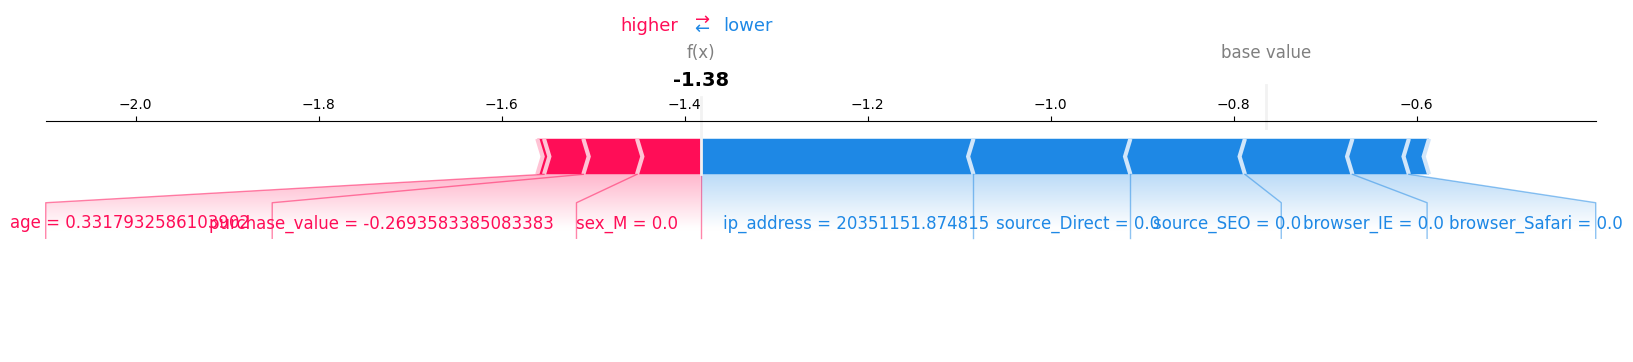

In [31]:
shap_force_plot(
    explainer,
    shap_values,
    X_test,
    fn_idx
)

3. Interpretation

3.1 Comparison of SHAP Importance and Built-in Feature Importance

The built-in XGBoost feature importance and SHAP analysis produced largely consistent results. Both methods identified customer acquisition source, IP address, age, purchase value, and browser characteristics as the primary drivers of fraud predictions.

However, SHAP provided additional insights by showing:

The direction of impact of each feature on fraud prediction.
Whether high or low feature values increase fraud risk.
How individual observations contribute to model decisions.

While built-in feature importance only ranks variables, SHAP explains why a transaction is classified as fraudulent.

3.2 Top 5 Drivers of Fraud Predictions

Based on the SHAP Summary Plot, the five most influential features are:

Rank	        Feature	         Impact on Fraud Prediction

1	         source_Direct	    Strongest predictor of fraud

2	         ip_address	        Significant geographic influence

3	        source_SEO	        Important acquisition channel indicator

4	          age	            Customer demographic effect

5	        purchase_value	      Transaction value influence

Source_Direct

Transactions originating from direct traffic tend to have higher positive SHAP values, indicating increased fraud risk.

IP Address

IP address contributes significantly to fraud prediction, suggesting strong geographic and network-related fraud patterns.

Source_SEO

Customers arriving through SEO channels exhibit different fraud behavior compared to other traffic sources.

Age

Certain age groups contribute more strongly to fraud predictions than others.

Purchase Value

Higher transaction amounts generally increase the probability of fraud detection.

3.3 Surprising or Counterintuitive Findings

Finding 1: Traffic Source Is More Important Than Purchase Amount

One surprising observation is that customer acquisition channels (Direct and SEO) have greater predictive power than purchase value.

This suggests fraudsters may use specific acquisition channels more frequently than legitimate customers.

Finding 2: Browser Type Plays a Significant Role

Internet Explorer, Firefox, Safari, and Opera appear among the most important features.

This indicates fraudsters may favor particular browsers or automated browser environments.

Finding 3: Gender Has Limited Impact

The variable sex_M appears near the bottom of the importance ranking.

This suggests gender contributes relatively little to fraud detection compared with behavioral and technical indicators.

Finding 4: IP Address Is Extremely Influential

IP-related information ranks among the strongest predictors.

This confirms that location and network behavior are critical components of fraud detection.

4. Business Recommendations

Recommendation 1: Apply Enhanced Verification for Direct Traffic Transactions

SHAP Insight

source_Direct is the most important fraud predictor.

Recommendation

Transactions originating from direct traffic should undergo additional verification, such as:

Multi-factor authentication

Email verification

Device verification

Expected Benefit


Reduces fraudulent activity originating from suspicious direct-access channels.

Recommendation 2: Implement Geographic Risk Scoring
SHAP Insight

IP address is the second most influential feature.

Recommendation

Develop IP-based risk scores and monitor:

       High-risk countries

       Suspicious IP ranges

       Anonymous proxy networks

       VPN traffic

Expected Benefit


Improves early fraud detection and reduces losses from high-risk regions.

Recommendation 3: Monitor High-Value Transactions More Closely
SHAP Insight

purchase_value positively influences fraud probability.

Recommendation

Introduce additional controls for transactions exceeding predefined thresholds.

Examples:Manual review

Expected Benefit

Reduces financial exposure from large fraudulent purchases.

Recommendation 4: Browser-Based Fraud Monitoring
SHAP Insight

browser_IE, browser_FireFox, browser_Safari, and browser_Opera contribute significantly to model predictions.

Recommendation

Flag transactions originating from browser-device combinations historically associated with fraud.

Expected Benefit

Improves identification of automated attacks and suspicious browsing behavior.

Recommendation 5: Risk-Based Customer Profiling
SHAP Insight

Age contributes meaningfully to fraud prediction.

Recommendation

Combine age with behavioral features such as:

         Purchase frequency

        Purchase value
        
        Traffic source

to build dynamic fraud risk profiles.

Expected Benefit

Improves fraud detection accuracy while reducing false positives.

Credit

In [32]:
best_model_credit = joblib.load(
    "../models/credit_best_model.pkl"
)

In [33]:
credit_df = load_data('../data/raw/creditcard.csv')

2026-06-13 18:27:15,870 - INFO - Loaded ../data/raw/creditcard.csv


In [34]:
credit_df = data_cleaning_pipeline(
    credit_df
)

credit_df.head()

2026-06-13 18:27:18,647 - INFO - Removed 1081 duplicates
2026-06-13 18:27:18,649 - INFO - Data types corrected
2026-06-13 18:27:18,828 - INFO - Missing values handled


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [35]:
credit_df = scale_features(
    credit_df,
    ["Time", "Amount"]
)
features_credit = credit_df.drop(
    "Class",
    axis=1
)

target_credit = credit_df["Class"]

In [36]:
from sklearn.model_selection import train_test_split
X = features_credit
y = target_credit

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )
)

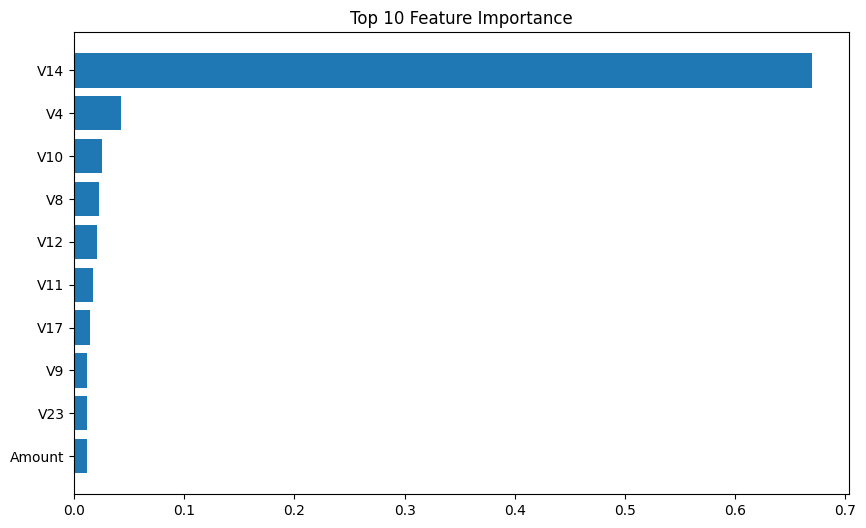

,Feature,Importance
14,V14,0.670164
4,V4,0.042120
10,V10,0.025597
8,V8,0.022858
12,V12,0.020769
11,V11,0.016695
17,V17,0.014725
9,V9,0.011985
23,V23,0.011854
29,Amount,0.011612


In [37]:
importance_df = plot_feature_importance(
    best_model_credit,
    X_test,
    top_n=10
)

importance_df


In [38]:
from explainability import (
    create_shap_explainer,
    shap_summary_plot
)


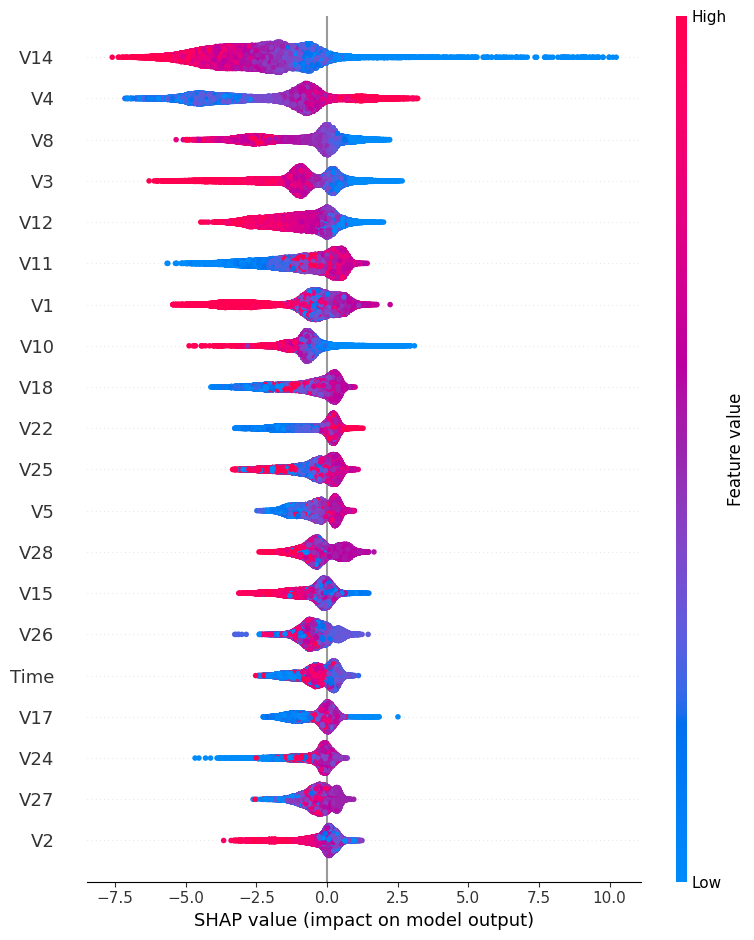

In [39]:
explainer = create_shap_explainer(
    best_model_credit
)
shap_values = shap_summary_plot(
    explainer,
    X_test)

In [40]:

y_pred = best_model_credit.predict(
    X_test
)


True Positive

In [41]:
results = X_test.copy()

results["actual"] = y_test.values
results["predicted"] = y_pred


False Positive

In [43]:
fp_idx = results[
    (results.actual == 0)
    &
    (results.predicted == 1)
].index[0]

fp_idx


np.int64(51602)

False Negative

In [44]:


fn_idx = results[
    (results.actual == 1)
    &
    (results.predicted == 0)
].index[0]

fn_idx


np.int64(240222)

In [45]:
y_pred = best_model_credit.predict(X_test)

In [46]:
import numpy as np

tp_idx = np.where((y_test == 1) & (y_pred == 1))[0][0]

fp_idx = np.where((y_test == 0) & (y_pred == 1))[0][0]

fn_idx = np.where((y_test == 1) & (y_pred == 0))[0][0]

print("TP:", tp_idx)
print("FP:", fp_idx)
print("FN:", fn_idx)

TP: 845
FP: 18977
FN: 1784


True Positive

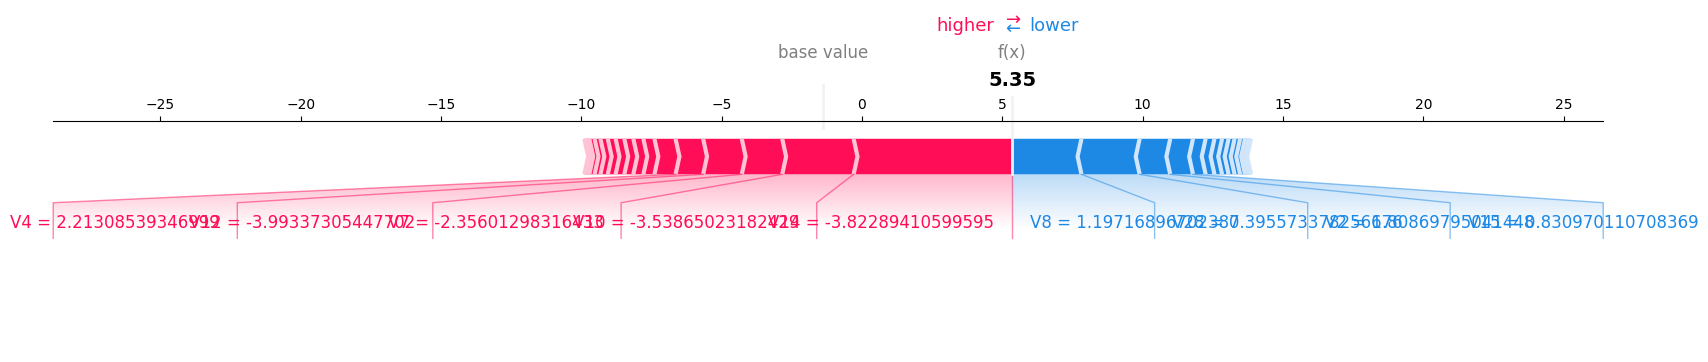

In [47]:
shap_force_plot(
    explainer,
    shap_values,
    X_test,
    tp_idx
)


False Positive

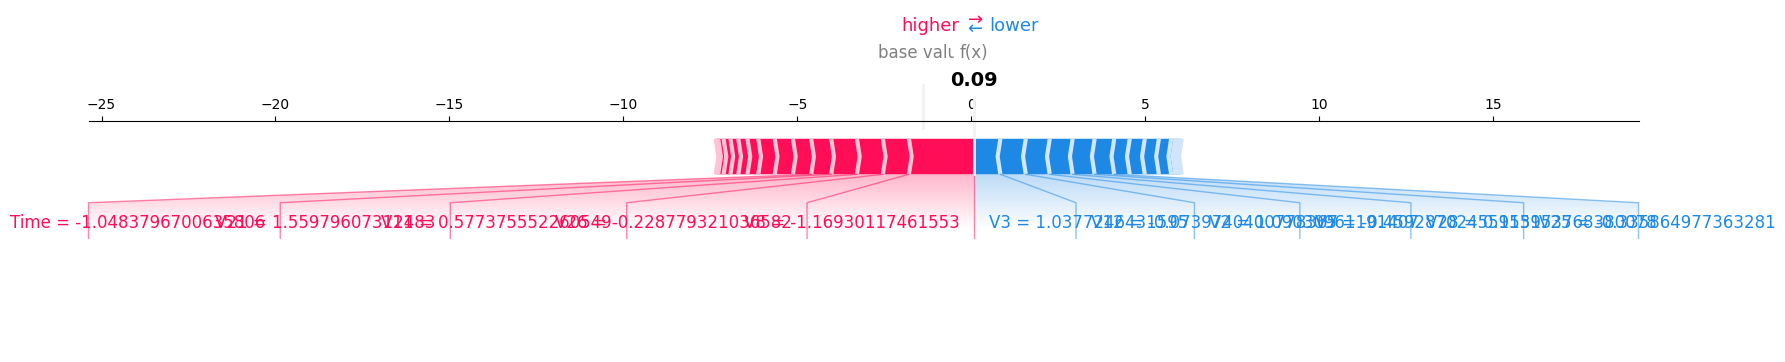

In [48]:

shap_force_plot(
    explainer,
    shap_values,
    X_test,
    fp_idx
)


False Negative

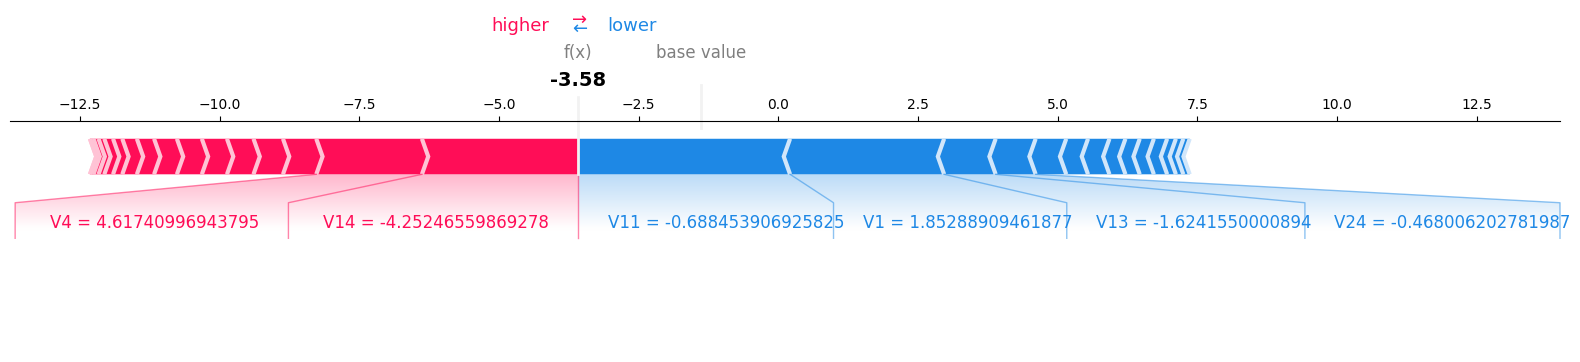

In [49]:
shap_force_plot(
    explainer,
    shap_values,
    X_test,
    fn_idx
)

3. Interpretation

3.1 Comparison of SHAP Importance vs Built-in Feature Importance

The built-in feature importance from the XGBoost model identified the most influential variables for fraud prediction. SHAP analysis validated these findings and provided additional insight into how each feature affects the model output.

Both methods consistently identified the following variables as highly influential:

V14,
V4,
V8,
V3,
V12

While XGBoost feature importance measures how frequently and effectively a feature is used for splitting, SHAP explains the direction and magnitude of each feature's contribution to fraud predictions.

Therefore, SHAP provides a more interpretable explanation of model behavior compared to standard feature importance scores.

3.2 Top 5 Drivers of Fraud Predictions

1. V14 (Most Important Feature)

Highest SHAP impact among all variables.
Low values of V14 strongly increase fraud probability.
High values of V14 generally decrease fraud probability.

Business Interpretation:

V14 represents a hidden transaction pattern generated during PCA transformation that strongly differentiates fraudulent transactions from legitimate ones.

2. V4

Higher V4 values increase fraud likelihood.
Lower values tend to reduce fraud risk.

Business Interpretation:

Transactions with unusual behavioral patterns represented by V4 are more likely to be fraudulent.

3. V8

Both extremely high and extremely low values influence fraud predictions.
Indicates nonlinear fraud behavior.

Business Interpretation:

Fraudsters may exhibit abnormal transaction patterns that differ significantly from normal customer behavior.

4. V3

Lower values of V3 push predictions toward fraud.
Higher values push predictions toward legitimate transactions.

Business Interpretation:

V3 captures latent transaction characteristics strongly associated with fraudulent activity.

5. V12

Lower values significantly increase fraud probability.
Consistent fraud indicator across observations.

Business Interpretation:

V12 contains hidden behavioral information useful for identifying abnormal transaction activity.

3.3 Surprising or Counterintuitive Findings

Finding 1: Amount is not among the top features

Contrary to common expectations, transaction amount was not one of the strongest predictors.

Implication:

Fraudulent transactions are not necessarily large transactions. Fraudsters often make small transactions to avoid detection.

Finding 2: Time has relatively low importance

The transaction timestamp contributes less than several PCA-generated variables.

Implication:

Fraud is driven more by transaction behavior patterns than by the specific time at which transactions occur.

Finding 3: PCA Components Dominate

Features such as V14, V4, V8, and V3 have much greater predictive power than raw variables.

Implication:

Hidden behavioral relationships are more important than obvious transaction characteristics.

4. Business Recommendations

Recommendation 1: High-Risk Transaction Scoring

SHAP Insight

V14, V4, and V12 contribute most strongly to fraud detection.

Action

Implement a real-time fraud scoring system using the trained XGBoost model.

Transactions with high fraud scores should:

       Trigger additional verification.

       Require OTP confirmation.

      Be temporarily held for review.

Expected Benefit

Reduction in fraudulent transactions before settlement.

Recommendation 2: Behavioral Monitoring Instead of Amount-Based Rules

SHAP Insight

Amount is not a major fraud predictor.

Action

Move away from rules such as:

"Flag all transactions above $10,000"

and instead focus on:

Behavioral anomalies,
Pattern deviations,
Model-based risk scores,
Expected Benefit

Higher fraud detection rates with fewer false alarms.

Recommendation 3: Prioritize Transactions with Extreme V14 and V12 Patterns

SHAP Insight

Very low values of V14 and V12 consistently drive fraud predictions.

Action

Create automated alerts when transactions exhibit these high-risk patterns.

Expected Benefit

Faster identification of suspicious transactions.

Recommendation 4: Deploy Real-Time XGBoost Monitoring
SHAP Insight

XGBoost achieved the highest performance:

Model	Mean F1	Mean AUC-PR

Logistic Regression	0.000	0.337

Random Forest	0.681	0.888

XGBoost	0.884	0.927

Action

Deploy XGBoost as the primary fraud detection engine and continuously monitor feature drift.

Expected Benefit

Improved fraud detection accuracy and reduced financial losses.